# Chronic mortality housing queue

This notebook sets up the baseline housing-allocation simulation for the next three figures. Time is measured in **years**, while the observed arrival and housing rates are entered per month and converted below.

The system has two true groups:

- **Chronic homelessness:** people remain in the queue unless housed or they die. In this model, chronic abandonment is interpreted as mortality before housing.
- **Non-chronic homelessness:** people may leave the queue by finding another housing arrangement; their patience is therefore shorter.

Housing is consumable: a monthly placement uses one unit permanently during the simulation horizon.

In [139]:
from dataclasses import dataclass
from functools import cached_property
from math import erf, exp, log, pi, sqrt
from pathlib import Path
import sys

from joblib import Parallel, delayed

# Find the repository's src directory regardless of where Jupyter starts.
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    src_dir = candidate / "src"
    if (src_dir / "gi_gi_n_gi_multiclass").is_dir():
        PROJECT_ROOT = candidate
        sys.path.insert(0, str(src_dir))
        break
else:
    raise ImportError("Could not find src/gi_gi_n_gi_multiclass from this notebook location.")

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.prehistory import generate_housing_queue_snapshot
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Deterministic, Exponential, LogNormal
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier
from gi_gi_n_gi_multiclass.outputs.schemas import customers_to_dataframe
from gi_gi_n_gi_multiclass.policies.naive_fcfs import NaiveFCFS
from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS

## Population, arrivals and housing

There are 750 new applicants per month, of whom 38% are truly chronic. The system starts with 8,000 people already waiting, allocated in the same proportions.

There are 250 new housing placements each month. No housing is available at time zero. Every person, including the initial queue, must wait at least six months before being eligible for an offer.

The policy gives people classified as chronic priority and uses FCFS within each assigned group. Classifier accuracy therefore determines how well scarce housing is directed to true chronic people.

In [151]:
MONTHS_PER_YEAR = 12

ARRIVALS_PER_MONTH = 750
CHRONIC_SHARE = 0.38
CHRONIC_ARRIVAL_RATE = ARRIVALS_PER_MONTH * CHRONIC_SHARE * MONTHS_PER_YEAR
NONCHRONIC_ARRIVAL_RATE = ARRIVALS_PER_MONTH * (1.0 - CHRONIC_SHARE) * MONTHS_PER_YEAR

INITIAL_QUEUE_SIZE = 8_000
MAX_PREHISTORY_YEARS = 25.0

HOUSING_PER_MONTH = 300
HOUSING_RELEASE_INTERVAL = 1.0 / MONTHS_PER_YEAR
FIRST_HOUSING_RELEASE = HOUSING_RELEASE_INTERVAL
INITIAL_HOUSING_STOCK = 0
ELIGIBILITY_DELAY = 6.0 / MONTHS_PER_YEAR

SIMULATION_YEARS = 10.0
SEED = 2026
POST_SNAPSHOT_SEED_OFFSET = 1_000_000

assert HOUSING_PER_MONTH < ARRIVALS_PER_MONTH

## Chronic mortality as abandonment

For chronic people, abandonment means death before housing. Mortality time follows a proper Gamma distribution with shape $$1.5$$. Its scale is solved so that cumulative mortality by 30 months is exactly 4%.

The Gamma curve is scaled so that

$$P(\text{death by }2.5\text{ years})=0.04.$$

Unlike the previous defective mixture, every chronic person now has a finite simulated lifetime. The fitted scale is approximately 16.66 years, giving a mean lifetime near 25 years while retaining the 4% short-horizon calibration. The non-chronic lognormal patience distribution is retained as the current working assumption from the parameter sheet and can be replaced when exit data are available.

In [141]:
@dataclass(frozen=True)
class ScaledGammaMortality:
    """Proper Gamma mortality time calibrated at a fixed horizon."""

    shape: float = 1.5
    calibration_window_years: float = 30.0 / 12.0
    mortality_by_window: float = 0.04

    @staticmethod
    def _shape_three_halves_cdf(x: float) -> float:
        if x <= 0.0:
            return 0.0
        return erf(sqrt(x)) - (2.0 / sqrt(pi)) * sqrt(x) * exp(-x)

    @cached_property
    def scale_years(self) -> float:
        if not np.isclose(self.shape, 1.5):
            raise ValueError("Closed-form calibration requires shape=1.5.")
        if not 0.0 < self.mortality_by_window < 1.0:
            raise ValueError("mortality_by_window must lie strictly between 0 and 1.")
        lower, upper = 0.0, 100.0
        for _ in range(100):
            midpoint = 0.5 * (lower + upper)
            if self._shape_three_halves_cdf(midpoint) < self.mortality_by_window:
                lower = midpoint
            else:
                upper = midpoint
        standardized_time = 0.5 * (lower + upper)
        return self.calibration_window_years / standardized_time

    def _gamma_cdf(self, time_years: float) -> float:
        return self._shape_three_halves_cdf(time_years / self.scale_years)

    def sample(self, rng: np.random.Generator) -> float:
        return float(rng.gamma(shape=self.shape, scale=self.scale_years))


chronic_mortality = ScaledGammaMortality()
# Working assumption: a substantial non-chronic share exits before the
# six-month eligibility point. Replace this with observed exit data.
NONCHRONIC_PATIENCE = LogNormal(meanlog=-1.0, sdlog=1.0)
nonchronic_exit_by_six_months = 0.5 * (
    1.0 + erf((log(0.5) - NONCHRONIC_PATIENCE.meanlog) / (NONCHRONIC_PATIENCE.sdlog * sqrt(2.0)))
)

mortality_check = chronic_mortality._gamma_cdf(chronic_mortality.calibration_window_years)
assert np.isclose(mortality_check, 0.04)
print(f"Calibrated chronic mortality by 30 months: {mortality_check:.1%}")
print(f"Fitted chronic mortality scale: {chronic_mortality.scale_years:.2f} years")
print(f"Implied mean chronic lifetime: {chronic_mortality.shape * chronic_mortality.scale_years:.2f} years")
print(f"Non-chronic exit probability by six months: {nonchronic_exit_by_six_months:.1%}")

Calibrated chronic mortality by 30 months: 4.0%
Fitted chronic mortality scale: 16.66 years
Implied mean chronic lifetime: 24.99 years
Non-chronic exit probability by six months: 62.1%


## Simulation configuration

New applicants arrive through ordinary renewal processes, here Poisson arrivals implemented through exponential interarrival times. Housing releases remain discrete and monthly.

The initial queue is generated by running the observed baseline system forward from empty until the unresolved population first reaches 8,000. During this prehistory, allocation is naive FCFS across everyone who has passed the six-month eligibility threshold: chronic status and assigned class do not affect who receives the next home. The resulting state is then treated as observed time zero. This is a finite-prehistory, first-passage assumption: it does not claim that this growing queue has a stationary age distribution.

Each survivor retains their historical arrival time, assigned class, residual patience and remaining eligibility delay. Consequently, eligibility and mortality/exit clocks are not restarted at time zero, and FCFS order is determined by simulated historical arrivals rather than true-class construction order. The chronic share of the snapshot is an output of arrivals, exits and allocations rather than being forced to equal the 38% incident share.

For each replication seed, one snapshot is generated under the naive baseline system (250 monthly placements and six-month eligibility) and reused across counterfactual scenarios. At observed time zero, every person in that snapshot is classified using the accuracy specified for the scenario; prehistory labels are discarded because classification did not govern naive allocations. Historical ages, residual patience and eligibility clocks remain fixed. The residual time to the next monthly housing release and any unused housing stock are also preserved. Post-snapshot random streams use a separate deterministic seed range so they do not replay the beginning of the prehistory streams.

The figure simulations use the same asymmetric classifier path as the earlier studies: for balanced accuracy $$a$$, sensitivity is $$a+0.05$$ and specificity is $$a-0.05$$.

In [142]:
chronic = CustomerClass(
    name="chronic",
    interarrival=Exponential(rate=CHRONIC_ARRIVAL_RATE),
    service=Deterministic(0.0),
    patience=chronic_mortality,
)

nonchronic = CustomerClass(
    name="nonchronic",
    interarrival=Exponential(rate=NONCHRONIC_ARRIVAL_RATE),
    service=Deterministic(0.0),
    patience=NONCHRONIC_PATIENCE,
)

classes = [chronic, nonchronic]
baseline_policy = PriorityFCFS(priority_order=[0, 1])
prehistory_policy = NaiveFCFS()

def classifier_from_accuracy(accuracy: float) -> ConfusionMatrixClassifier:
    sensitivity = accuracy + 0.05
    specificity = accuracy - 0.05
    if not (0.0 <= sensitivity <= 1.0 and 0.0 <= specificity <= 1.0):
        raise ValueError("Accuracy must keep sensitivity and specificity in [0, 1].")
    return ConfusionMatrixClassifier(
        np.array([
            [sensitivity, 1.0 - sensitivity],
            [1.0 - specificity, specificity],
        ])
    )

def make_baseline_config(
    seed: int = SEED,
    run_years: float = SIMULATION_YEARS,
    classifier_accuracy: float = 0.8,
    housing_per_month: int = HOUSING_PER_MONTH,
    mandatory_wait_months: int = 6,
    initial_queue=None,
    first_housing_release: float = FIRST_HOUSING_RELEASE,
    initial_housing_stock: int = INITIAL_HOUSING_STOCK,
    allocation_policy=None,
    classify_initial_queue: bool = False,
) -> MultiSimConfig:
    if allocation_policy is None:
        allocation_policy = baseline_policy
    return MultiSimConfig(
        n_servers=int(housing_per_month),
        classes=classes,
        policy=allocation_policy,
        classifier=classifier_from_accuracy(classifier_accuracy),
        seed=seed,
        warmup_time=0.0,
        run_time=run_years,
        housing_mode=True,
        housing_arrival_mode="renewal",
        last_arrival_time=run_years,
        initial_queue=initial_queue,
        classify_initial_queue=classify_initial_queue,
        housing_release_interval=HOUSING_RELEASE_INTERVAL,
        first_housing_release=first_housing_release,
        initial_housing_stock=initial_housing_stock,
        eligibility_delay=mandatory_wait_months / MONTHS_PER_YEAR,
        collect_event_log=False,
    )


def make_prehistory_snapshot(seed: int = SEED):
    prehistory_config = make_baseline_config(
        seed=seed,
        run_years=MAX_PREHISTORY_YEARS,
        classifier_accuracy=0.8,
        housing_per_month=HOUSING_PER_MONTH,
        mandatory_wait_months=6,
        initial_queue=None,
        allocation_policy=prehistory_policy,
    )
    return generate_housing_queue_snapshot(
        prehistory_config,
        INITIAL_QUEUE_SIZE,
        max_prehistory_time=MAX_PREHISTORY_YEARS,
    )


def run_baseline(
    seed: int = SEED,
    run_years: float = SIMULATION_YEARS,
    classifier_accuracy: float = 0.8,
    housing_per_month: int = HOUSING_PER_MONTH,
    mandatory_wait_months: int = 6,
):
    snapshot = make_prehistory_snapshot(seed)
    result = run_sim_multi(
        make_baseline_config(
            seed=seed + POST_SNAPSHOT_SEED_OFFSET,
            run_years=run_years,
            classifier_accuracy=classifier_accuracy,
            housing_per_month=housing_per_month,
            mandatory_wait_months=mandatory_wait_months,
            initial_queue=snapshot.customers,
            first_housing_release=snapshot.time_to_next_housing_release,
            initial_housing_stock=snapshot.available_housing,
            classify_initial_queue=True,
        )
    )
    customers = customers_to_dataframe(result)
    customers["is_initial_queue"] = customers["customer_id"] < INITIAL_QUEUE_SIZE
    return result, customers

## Baseline parameters

This table is a compact check on the quantities that will remain fixed across the three forthcoming figures.

In [143]:
pd.DataFrame(
    [
        ("New applicants", ARRIVALS_PER_MONTH, "per month"),
        ("True chronic share", CHRONIC_SHARE, "proportion"),
        ("Initial queue", INITIAL_QUEUE_SIZE, "people"),
        ("Initial queue construction", "baseline prehistory", "first passage to target"),
        ("Housing released", HOUSING_PER_MONTH, "placements per month"),
        ("Minimum eligibility wait", ELIGIBILITY_DELAY * MONTHS_PER_YEAR, "months"),
        ("Chronic mortality by 30 months", mortality_check, "proportion"),
        ("Non-chronic exit by six months", nonchronic_exit_by_six_months, "proportion"),
    ],
    columns=["Parameter", "Value", "Unit"],
)

,Parameter,Value,Unit
0,New applicants,750,per month
1,True chronic share,0.38,proportion
2,Initial queue,8000,people
3,Initial queue construction,baseline prehistory,first passage to target
4,Housing released,250,placements per month
5,Minimum eligibility wait,6.0,months
6,Chronic mortality by 30 months,0.04,proportion
7,Non-chronic exit by six months,0.620522,proportion


## Figure simulations

All four figures use the chronic mortality outcome $$P(\text{death before housing} \mid \text{true chronic})$$. Queue length is the unresolved on-street population at the end of a five-year horizon, split by true class.

The final contour uses 1 to 12 months.

In [152]:
FIGURE_HORIZON_YEARS = 20.0
# Average every plotted scenario over independent replications.
FIGURE_SEEDS = list(range(1, 11))
# More processes than physical CPU cores slows the simulation through contention.
# Set to 1 for serial debugging.
N_WORKERS = 16

WAIT_MONTH_GRID = np.arange(1, 13)
PLOT_ACCURACIES = [0.55, 0.70, 0.85]
CONTOUR_ACCURACIES = np.arange(0.5, 0.91, 0.1)
# The wait-time figures need both the plotted and contour accuracy values.
WAIT_GRID_ACCURACIES = np.array(sorted(set(PLOT_ACCURACIES).union(CONTOUR_ACCURACIES)))
HOUSING_SUPPLY_GRID = np.arange(100, 501, 50)

# Shared figure geometry and typography. Every saved figure uses this
# same canvas, so font sizes remain visually comparable across figures.
FIGURE_WIDTH = 7.0
FIGURE_HEIGHT = 5.0
FIGURE_SIZE = (FIGURE_WIDTH, FIGURE_HEIGHT)
# Separate geometry for the optional three-panel version of Figure 2.
FIGURE_2_COMBINED_WIDTH = 11.0
FIGURE_2_COMBINED_HEIGHT = 4.0
FIGURE_DPI = 200
FONT_SIZE = 13
TITLE_FONT_SIZE = FONT_SIZE * 1.2

matplotlib.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.titlesize": TITLE_FONT_SIZE,
})

def save_figure(fig, filename, rect=None):
    fig.tight_layout(pad=0.8, rect=rect)
    fig.savefig(FIGURE_DIR / filename, dpi=FIGURE_DPI)

FIGURE_DIR = PROJECT_ROOT / "04_homeless_studies" / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

def summarise_scenario(classifier_accuracy, housing_per_month, mandatory_wait_months, seed, snapshot):
    # Figure grids only need aggregate outcomes. Avoid constructing a large
    # pandas table for every scenario.
    result = run_sim_multi(
        make_baseline_config(
            seed=seed + POST_SNAPSHOT_SEED_OFFSET,
            run_years=FIGURE_HORIZON_YEARS,
            classifier_accuracy=classifier_accuracy,
            housing_per_month=housing_per_month,
            mandatory_wait_months=mandatory_wait_months,
            initial_queue=snapshot.customers,
            first_housing_release=snapshot.time_to_next_housing_release,
            initial_housing_stock=snapshot.available_housing,
            classify_initial_queue=True,
        )
    )
    chronic_total = 0
    chronic_deaths = 0
    end_queue_chronic = 0
    end_queue_nonchronic = 0
    for customer in result.customers:
        if customer.true_class_id == 0:
            chronic_total += 1
            chronic_deaths += customer.outcome == "ABANDONED"
        if customer.outcome == "IN_SYSTEM_END":
            if customer.true_class_id == 0:
                end_queue_chronic += 1
            else:
                end_queue_nonchronic += 1
    return {
        "classifier_accuracy": classifier_accuracy,
        "housing_per_month": housing_per_month,
        "mandatory_wait_months": mandatory_wait_months,
        "seed": seed,
        "chronic_mortality_probability": chronic_deaths / chronic_total,
        "end_queue_chronic": end_queue_chronic,
        "end_queue_nonchronic": end_queue_nonchronic,
    }

def run_grid(accuracies, housing_values, wait_months):
    # Reuse the inspected baseline snapshots for every counterfactual.
    snapshots = PREHISTORY_SNAPSHOTS
    scenarios = [
        (float(accuracy), int(housing_per_month), int(mandatory_wait_months), int(seed), snapshots[seed])
        for accuracy in accuracies
        for housing_per_month in housing_values
        for mandatory_wait_months in wait_months
        for seed in FIGURE_SEEDS
    ]
    rows = Parallel(n_jobs=N_WORKERS, prefer="processes")(
        delayed(summarise_scenario)(*scenario) for scenario in scenarios
    )
    return pd.DataFrame(rows)

def mean_outcomes(raw):
    return raw.groupby(
        ["classifier_accuracy", "housing_per_month", "mandatory_wait_months"],
        as_index=False,
    ).mean(numeric_only=True)

## Initial queue diagnostics across replications

Before running counterfactuals, we generate and inspect the naive-FCFS first-passage snapshot for every replication seed. These diagnostics are part of the model check: they show the historical ages and composition implied by the assumed arrival, exit, eligibility and housing processes when chronic classification does not influence prehistory allocations.

The true chronic share need not equal the 38% incident share because the initial queue is a survivor population. Assigned composition is not reported here because the entire snapshot is classified separately at observed time zero for each scenario accuracy. Residual patience is not a fresh draw: it is the remaining time on the mortality or exit clock originally sampled at historical arrival. The exact underlying snapshots summarized here are reused in all subsequent figure scenarios.

In [153]:
generated_snapshots = Parallel(n_jobs=N_WORKERS, prefer="processes")(
    delayed(make_prehistory_snapshot)(int(seed)) for seed in FIGURE_SEEDS
)
PREHISTORY_SNAPSHOTS = dict(zip(FIGURE_SEEDS, generated_snapshots))

snapshot_rows = []
snapshot_class_rows = []
for seed, snapshot in PREHISTORY_SNAPSHOTS.items():
    ages = np.array([customer.age for customer in snapshot.customers])
    true_classes = np.array([customer.true_class_id for customer in snapshot.customers])
    eligible = np.array([customer.remaining_eligibility <= 0.0 for customer in snapshot.customers])
    residuals = np.array([
        np.nan if customer.residual_patience is None else customer.residual_patience
        for customer in snapshot.customers
    ])
    finite_residual = np.isfinite(residuals)
    snapshot_rows.append({
        "seed": seed,
        "prehistory_years": snapshot.prehistory_time,
        "true_chronic_share": np.mean(true_classes == 0),
        "eligible_share": eligible.mean(),
        "mean_age_months": ages.mean() * MONTHS_PER_YEAR,
        "median_age_months": np.median(ages) * MONTHS_PER_YEAR,
        "p90_age_months": np.quantile(ages, 0.90) * MONTHS_PER_YEAR,
        "finite_residual_share": finite_residual.mean(),
        "median_finite_residual_months": (
            np.median(residuals[finite_residual]) * MONTHS_PER_YEAR
            if finite_residual.any() else np.nan
        ),
        "available_housing": snapshot.available_housing,
    })
    for true_class_id, class_name in enumerate(["chronic", "nonchronic"]):
        in_class = true_classes == true_class_id
        class_ages = ages[in_class]
        snapshot_class_rows.append({
            "seed": seed,
            "true_class": class_name,
            "count": in_class.sum(),
            "share": in_class.mean(),
            "eligible_share": eligible[in_class].mean(),
            "mean_age_months": class_ages.mean() * MONTHS_PER_YEAR,
            "median_age_months": np.median(class_ages) * MONTHS_PER_YEAR,
            "p90_age_months": np.quantile(class_ages, 0.90) * MONTHS_PER_YEAR,
            "finite_residual_share": finite_residual[in_class].mean(),
        })

snapshot_seed_summary = pd.DataFrame(snapshot_rows)
snapshot_class_by_seed = pd.DataFrame(snapshot_class_rows)
snapshot_overall_summary = snapshot_seed_summary.drop(columns="seed").agg(
    ["mean", "std", "min", "max"]
).T
snapshot_class_summary = snapshot_class_by_seed.groupby("true_class").agg(
    mean_count=("count", "mean"),
    sd_count=("count", "std"),
    mean_share=("share", "mean"),
    mean_eligible_share=("eligible_share", "mean"),
    mean_age_months=("mean_age_months", "mean"),
    mean_median_age_months=("median_age_months", "mean"),
    mean_p90_age_months=("p90_age_months", "mean"),
    mean_finite_residual_share=("finite_residual_share", "mean"),
)

display(snapshot_overall_summary.round(3))
display(snapshot_class_summary.round(3))

,mean,std,min,max
prehistory_years,8.288,0.504,7.497,9.249
true_chronic_share,0.637,0.006,0.628,0.649
eligible_share,0.549,0.005,0.542,0.558
mean_age_months,7.609,0.104,7.449,7.825
median_age_months,6.863,0.108,6.721,7.088
p90_age_months,15.466,0.206,15.110,15.889
finite_residual_share,1.000,0.000,1.000,1.000
median_finite_residual_months,101.049,3.208,94.604,105.746
available_housing,0.000,0.000,0.000,0.000


,mean_count,sd_count,mean_share,mean_eligible_share,mean_age_months,mean_median_age_months,mean_p90_age_months,mean_finite_residual_share
true_class,,,,,,,,
chronic,5093.3,46.672,0.637,0.665,8.964,9.008,16.092,1.0
nonchronic,2906.7,46.672,0.363,0.345,5.236,3.897,12.346,1.0


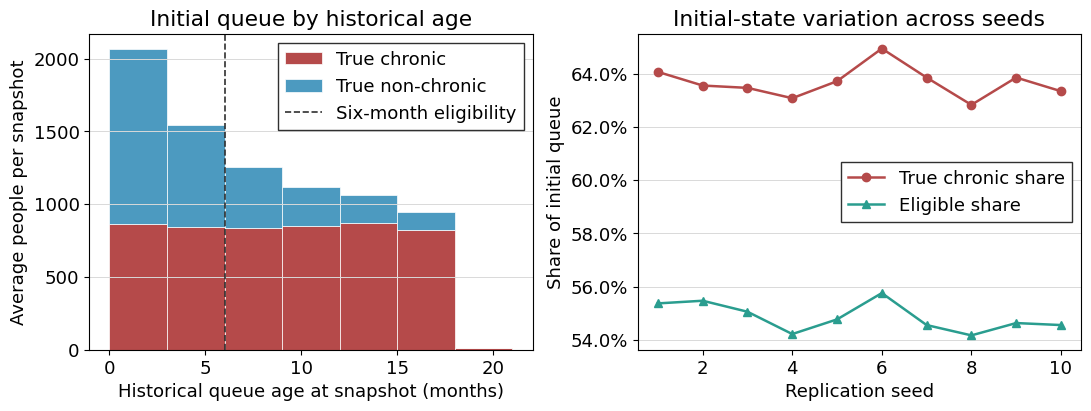

In [154]:
# Visual check of the initial populations used by the counterfactuals.
pooled_ages_months = {0: [], 1: []}
for snapshot in PREHISTORY_SNAPSHOTS.values():
    for customer in snapshot.customers:
        pooled_ages_months[customer.true_class_id].append(
            customer.age * MONTHS_PER_YEAR
        )

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
class_colours = {0: "#B54A4A", 1: "#4C9AC0"}
class_labels = {0: "True chronic", 1: "True non-chronic"}
age_arrays = [np.asarray(pooled_ages_months[class_id]) for class_id in (0, 1)]
bin_width_months = 3.0
maximum_age = max(ages.max() for ages in age_arrays)
age_bins = np.arange(
    0.0, np.ceil(maximum_age / bin_width_months) * bin_width_months + bin_width_months,
    bin_width_months,
)
snapshot_weight = 1.0 / len(PREHISTORY_SNAPSHOTS)
axes[0].hist(
    age_arrays, bins=age_bins, stacked=True,
    weights=[np.full(len(ages), snapshot_weight) for ages in age_arrays],
    color=[class_colours[0], class_colours[1]],
    label=[class_labels[0], class_labels[1]],
    edgecolor="white", linewidth=0.5,
)
axes[0].axvline(6, color="#303030", linestyle="--", linewidth=1.2, label="Six-month eligibility")
axes[0].set(
    xlabel="Historical queue age at snapshot (months)",
    ylabel="Average people per snapshot",
    title="Initial queue by historical age",
)
axes[0].grid(axis="y", color="#D9D9D9", linewidth=0.7)
axes[0].legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")

axes[1].plot(
    snapshot_seed_summary["seed"], snapshot_seed_summary["true_chronic_share"],
    marker="o", linewidth=1.8, color="#B54A4A", label="True chronic share",
)
axes[1].plot(
    snapshot_seed_summary["seed"], snapshot_seed_summary["eligible_share"],
    marker="^", linewidth=1.8, color="#2A9D8F", label="Eligible share",
)
axes[1].set(
    xlabel="Replication seed", ylabel="Share of initial queue",
    title="Initial-state variation across seeds",
)
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].grid(axis="y", color="#D9D9D9", linewidth=0.7)
axes[1].legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")

save_figure(fig, "figure_0_initial_queue_diagnostics.png")
plt.show()

## Figure 1: chronic mortality versus mandatory wait

A short enforced wait makes false-positive non-chronic people eligible quickly. A longer wait lets some leave before taking housing capacity, but an overly long wait exposes true chronic people to mortality.

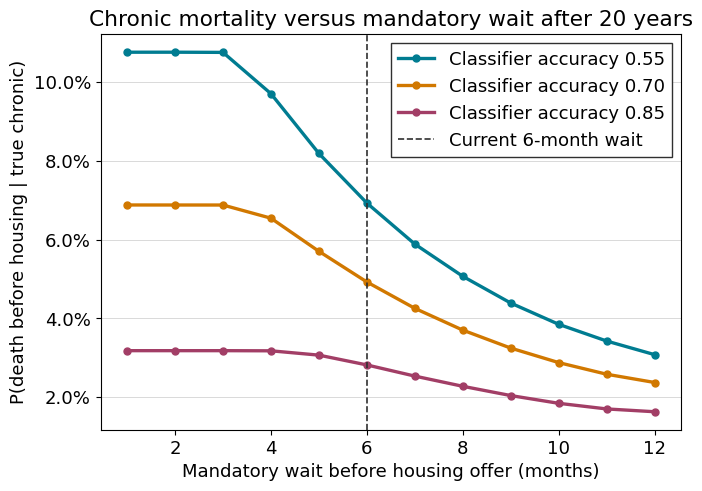

In [ ]:
wait_raw = run_grid(WAIT_GRID_ACCURACIES, [HOUSING_PER_MONTH], WAIT_MONTH_GRID)
wait_replication_counts = wait_raw.groupby(
    ["classifier_accuracy", "housing_per_month", "mandatory_wait_months"]
).size()
assert wait_replication_counts.eq(len(FIGURE_SEEDS)).all(), "Incomplete wait-grid replications"
wait_summary = mean_outcomes(wait_raw)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
line_colours = {0.55: "#007C91", 0.70: "#D17800", 0.85: "#A23E66"}
for accuracy in PLOT_ACCURACIES:
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy]
    ax.plot(data["mandatory_wait_months"], data["chronic_mortality_probability"], color=line_colours[accuracy], marker="o", markersize=5, linewidth=2.4, label=f"Classifier accuracy {accuracy:.2f}")
ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2, label="Current 6-month wait")
ax.set(xlabel="Mandatory wait before housing offer (months)", ylabel="P(death before housing | true chronic)", title=f"Chronic mortality versus mandatory wait after {FIGURE_HORIZON_YEARS:g} years")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
# ax.set_ylim(0.0151, 0.0225)
legend = ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_linewidth(1.0)

save_figure(fig, "figure_1_mortality_vs_wait.png")
plt.show()

## Figure 2: end-of-horizon queue composition

The stacked bars show the unresolved population after five years. Accuracy should mostly change who receives housing and therefore mortality, rather than create housing or mechanically reduce the total on-street population.

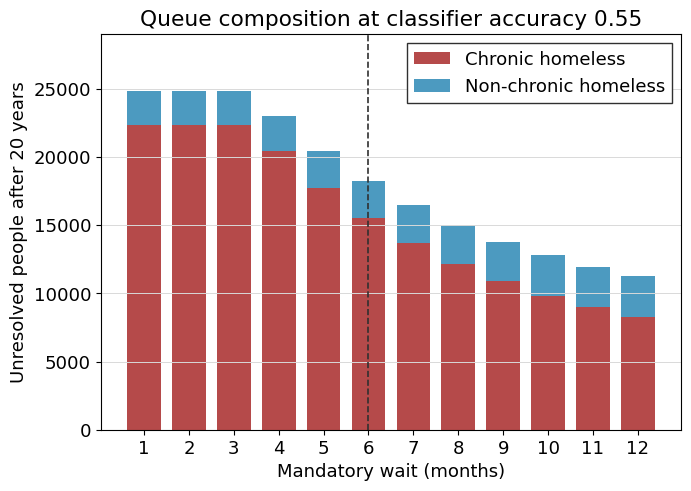

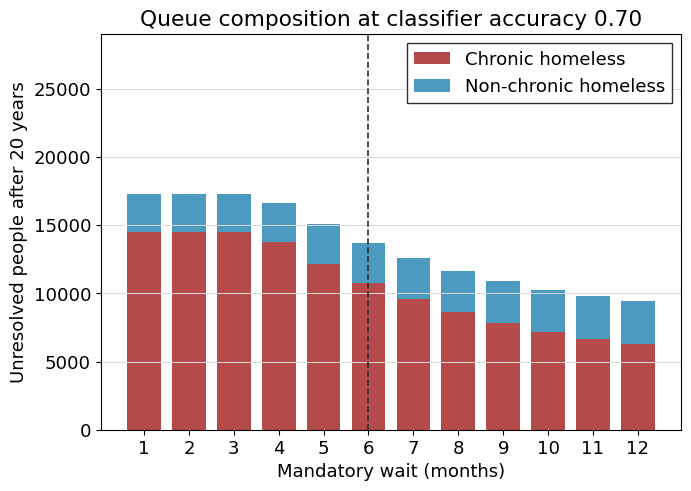

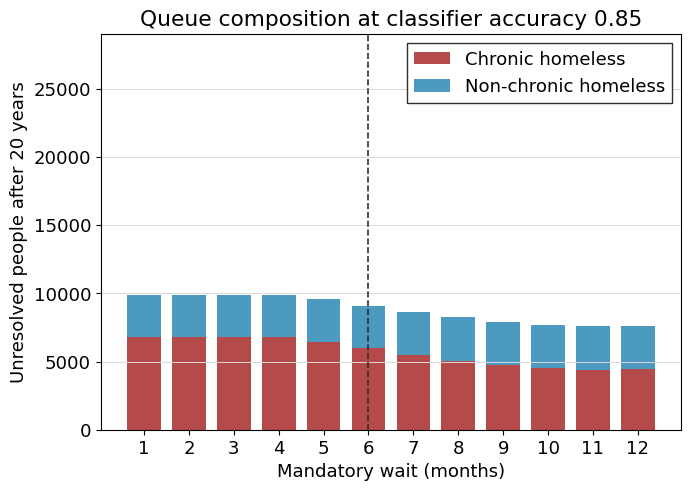

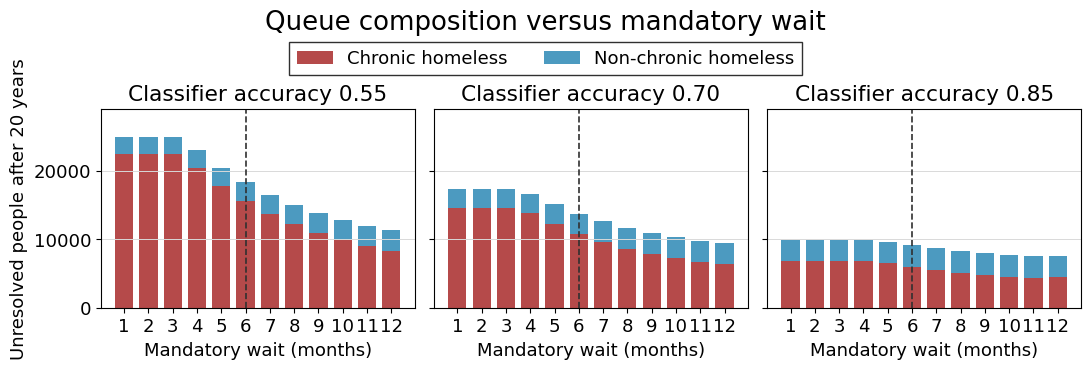

In [156]:
queue_total_max = (wait_summary["end_queue_chronic"] + wait_summary["end_queue_nonchronic"]).max()
for accuracy in PLOT_ACCURACIES:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy].sort_values("mandatory_wait_months")
    waits = data["mandatory_wait_months"]
    chronic_queue = data["end_queue_chronic"]
    nonchronic_queue = data["end_queue_nonchronic"]
    ax.bar(waits, chronic_queue, width=0.75, color="#B54A4A", label="Chronic homeless")
    ax.bar(waits, nonchronic_queue, width=0.75, bottom=chronic_queue, color="#4C9AC0", label="Non-chronic homeless")
    ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2)
    ax.set(
        title=f"Queue composition at classifier accuracy {accuracy:.2f}",
        xlabel="Mandatory wait (months)",
        ylabel=f"Unresolved people after {FIGURE_HORIZON_YEARS:g} years",
        xticks=WAIT_MONTH_GRID,
        ylim=(0, queue_total_max * 1.06),
    )
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
    ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030", loc="upper right")
    accuracy_tag = f"{accuracy:.2f}".replace(".", "_")
    save_figure(fig, f"figure_2_queue_composition_accuracy_{accuracy_tag}.png")
    plt.show()

# Optional combined version, retaining the original Figure 2 title.
fig, axes = plt.subplots(
    1,
    len(PLOT_ACCURACIES),
    figsize=(FIGURE_2_COMBINED_WIDTH, FIGURE_2_COMBINED_HEIGHT),
    sharey=True,
)
for ax, accuracy in zip(axes, PLOT_ACCURACIES):
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy].sort_values("mandatory_wait_months")
    waits = data["mandatory_wait_months"]
    chronic_queue = data["end_queue_chronic"]
    nonchronic_queue = data["end_queue_nonchronic"]
    ax.bar(waits, chronic_queue, width=0.75, color="#B54A4A", label="Chronic homeless")
    ax.bar(waits, nonchronic_queue, width=0.75, bottom=chronic_queue, color="#4C9AC0", label="Non-chronic homeless")
    ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2)
    ax.set(
        title=f"Classifier accuracy {accuracy:.2f}",
        xlabel="Mandatory wait (months)",
        xticks=WAIT_MONTH_GRID,
        ylim=(0, queue_total_max * 1.06),
    )
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
axes[0].set_ylabel(f"Unresolved people after {FIGURE_HORIZON_YEARS:g} years")
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle("Queue composition versus mandatory wait", fontsize=1.2 * TITLE_FONT_SIZE, y=0.91)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.85),
    ncol=2,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="#303030",
)
save_figure(fig, "figure_2_queue_composition_combined.png", rect=(0, 0, 1, 0.86))
plt.show()

## Figure 3: housing supply versus classifier accuracy

Each isoline joins combinations of monthly housing supply and classifier accuracy that give the same mean chronic mortality outcome at a six-month wait. Every grid point is averaged over the same replication seeds used in Figures 1 and 2.

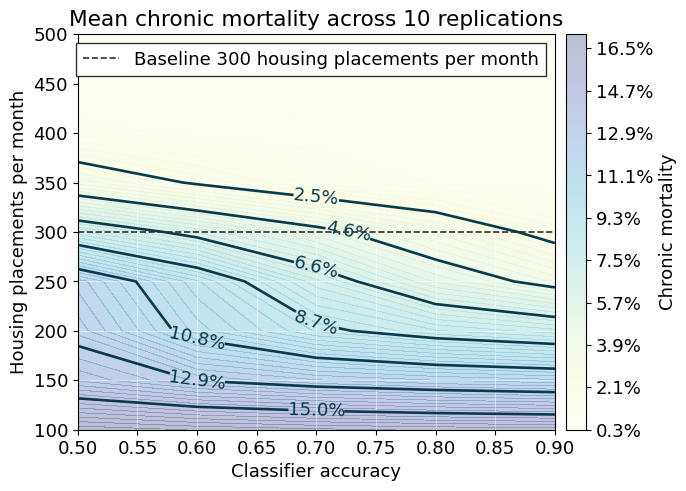

In [157]:
supply_raw = run_grid(CONTOUR_ACCURACIES, HOUSING_SUPPLY_GRID, [6])
supply_replication_counts = supply_raw.groupby(
    ["classifier_accuracy", "housing_per_month", "mandatory_wait_months"]
).size()
assert supply_replication_counts.eq(len(FIGURE_SEEDS)).all(), "Incomplete supply-grid replications"
supply_summary = mean_outcomes(supply_raw)
supply_surface = supply_summary.pivot(index="housing_per_month", columns="classifier_accuracy", values="chronic_mortality_probability")
x_accuracy, y_housing = np.meshgrid(supply_surface.columns.to_numpy(), supply_surface.index.to_numpy())

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
supply_values = supply_surface.to_numpy()
supply_levels = np.linspace(supply_values.min(), supply_values.max(), 9)
background = ax.contourf(x_accuracy, y_housing, supply_values, levels=64, cmap="YlGnBu", alpha=0.28)
contours = ax.contour(x_accuracy, y_housing, supply_values, levels=supply_levels, colors="#073B4C", linewidths=1.9)
ax.clabel(contours, inline=True, inline_spacing=3, fontsize=FONT_SIZE, fmt=lambda x: f"{x:.1%}")
colourbar = fig.colorbar(background, ax=ax, pad=0.02, format=PercentFormatter(xmax=1.0, decimals=1))
colourbar.set_label("Chronic mortality")
ax.axhline(HOUSING_PER_MONTH, color="#303030", linestyle="--", linewidth=1.2, label=f"Baseline {HOUSING_PER_MONTH} housing placements per month")
ax.set(xlabel="Classifier accuracy", ylabel="Housing placements per month", title=f"Mean chronic mortality across {len(FIGURE_SEEDS)} replications")
ax.grid(color="white", linewidth=0.6, alpha=0.55)
ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
save_figure(fig, "figure_3_supply_accuracy_isolines.png")
plt.show()

## Figure 4: mandatory wait versus classifier accuracy

These isolines show whether a more accurate classifier can support a shorter mandatory wait while retaining the same mean chronic mortality outcome at the baseline housing supply. They reuse the same seed-averaged wait grid as Figures 1 and 2.

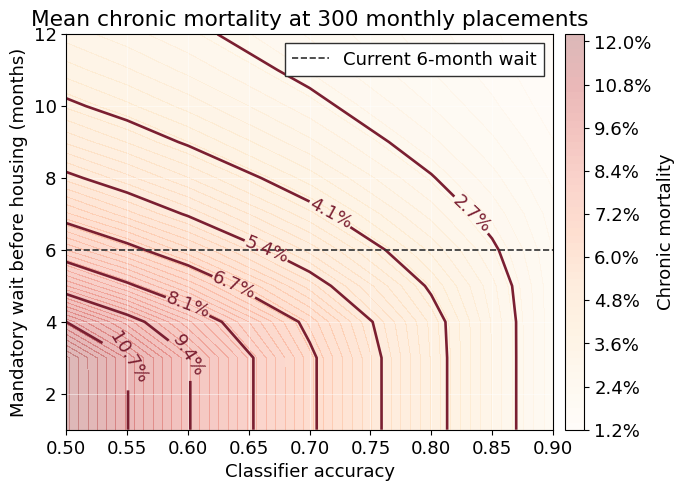

In [158]:
wait_surface = wait_summary.pivot(index="mandatory_wait_months", columns="classifier_accuracy", values="chronic_mortality_probability")
x_accuracy, y_wait = np.meshgrid(wait_surface.columns.to_numpy(), wait_surface.index.to_numpy())

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
wait_values = wait_surface.to_numpy()
wait_levels = np.linspace(wait_values.min(), wait_values.max(), 9)
background = ax.contourf(x_accuracy, y_wait, wait_values, levels=64, cmap="OrRd", alpha=0.28)
contours = ax.contour(x_accuracy, y_wait, wait_values, levels=wait_levels, colors="#7A1F31", linewidths=1.9)
ax.clabel(contours, inline=True, inline_spacing=3, fontsize=FONT_SIZE, fmt=lambda x: f"{x:.1%}")
colourbar = fig.colorbar(background, ax=ax, pad=0.02, format=PercentFormatter(xmax=1.0, decimals=1))
colourbar.set_label("Chronic mortality")
ax.axhline(6, color="#303030", linestyle="--", linewidth=1.2, label="Current 6-month wait")
ax.set(xlabel="Classifier accuracy", ylabel="Mandatory wait before housing (months)", title=f"Mean chronic mortality at {HOUSING_PER_MONTH} monthly placements")
ax.grid(color="white", linewidth=0.6, alpha=0.55)
ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
save_figure(fig, "figure_4_wait_accuracy_isolines.png")
plt.show()